# Dynamic Chunking by Information Density (follow-up to `information_capacity_signals`)

**Question.** For natural-language inputs of varying **information density**, if we let the recurrent
state accumulate until its **capacity signal plateaus** and *chunk* there (snapshot the state, reset,
continue) — **does the chunk length depend on the input's information density?**

This generalizes the repo's per-head rank-saturation point `T*` into a **density-dependent** boundary,
and is the training-free analogue of [H-Net dynamic chunking](https://arxiv.org/abs/2507.07955)
(which adapts segment length to information content).

### Two competing hypotheses (we measure which one holds — and its sign)
- **(A) Compression view (H-Net-like):** low-info regions get absorbed into *longer* chunks →
  `chunk length ∝ 1 / density`  (Spearman ρ < 0).
- **(B) Saturation view:** repetitive/low-density input makes the state's eRank saturate *fast*, so we
  cut *early* → `chunk length ∝ density`  (ρ > 0).

### Design (decisions locked in)
- **Density knob:** *controlled repetition/dilution* — a unique window of length `unique_frac·L` tiled
  to length `L`. `unique_frac=1.0` = all-novel (high density); small = short window repeated (low).
  Realized density is measured empirically as **bits/token** (S2).
- **Chunk boundary:** *two criteria, compared* — (i) **eRank saturation** (reach `sat_frac` of the
  window's max eRank) and (ii) **epiplexity** (reach `sat_frac` of cumulative in-context surprisal).
- **Model:** `mamba2-370m` first (single clean state; ties to the repo's `T*`).

> Shared code (loaders, state extraction, S1–S3) lives in `capacity_utils.py`.
> **(3)** — testing whether the chunked states still work under the LLM-memory-routing **SSC** scheme —
> is deferred to a later notebook.

## 0. Setup
Run on a CUDA box (see the SLURM script). Uses the `sh_infocap` env.

In [1]:
# !pip install torch transformers datasets mamba-ssm causal-conv1d matplotlib scipy  # (already in sh_infocap)

## 1. Imports

In [2]:
import os, sys, json, math
import numpy as np
import torch
import matplotlib.pyplot as plt
sys.path.insert(0, os.getcwd())          # notebooks/ (SLURM runs here); capacity_utils.py lives here
from capacity_utils import (DEVICE, load_bundle, effective_rank,
                            S1_erank, S2_pred_entropy, S3_epiplexity)

RESULTS_DIR = os.path.join(os.getcwd(), "chunking_results")
os.makedirs(RESULTS_DIR, exist_ok=True)
print("device:", DEVICE, "| results ->", RESULTS_DIR)

device: cuda | results -> /home/sohyung/SSM_Rank_Analysis/notebooks/chunking_results


## 2. Information-density–controlled sequences
`unique_frac` is the knob: a window of `≈unique_frac·L` fresh WikiText tokens tiled up to length `L`.
Small ⇒ short window repeated many times ⇒ the model quickly predicts the repeats ⇒ **low density**.
We report the *realized* density as the model's mean **bits/token**.

In [3]:
def build_text_pool(tokenizer, dataset="Salesforce/wikitext", config="wikitext-2-raw-v1",
                    split="test", max_tokens=200000):
    from datasets import load_dataset
    ds = load_dataset(dataset, config, split=split)
    toks = []
    for line in ds["text"]:
        if line.strip():
            toks.extend(tokenizer(line).input_ids)
        if len(toks) >= max_tokens:
            break
    return np.array(toks[:max_tokens], dtype=np.int64)

def make_repetition_sequence(pool, L=256, unique_frac=1.0, seed=0):
    """Unique window of length ~unique_frac*L tiled to length L. Low unique_frac -> low density."""
    rng = np.random.default_rng(seed)
    w = max(1, int(round(L * unique_frac)))
    s = int(rng.integers(0, max(1, len(pool) - w)))
    window = pool[s:s + w]
    seq = np.tile(window, int(np.ceil(L / w)))[:L]
    return torch.tensor(seq, dtype=torch.long).unsqueeze(0)

def realized_density(bundle, ids):
    """Empirical information density = mean bits/token under the model (S2)."""
    return S2_pred_entropy(bundle, ids)["bits_per_token"]

## 3. Capacity-plateau chunking (two criteria)
Segment one long sequence into chunks: within each chunk we grow the prefix until the capacity signal
reaches `sat_frac` of what it would reach in the remaining window, then cut, **reset the state**, and
continue from there. `chunk length` = the cut position.

- **eRank criterion:** eRank of the (reset) state after `k` tokens; cut at first `k` reaching
  `sat_frac · max_k eRank`.
- **epiplexity criterion:** cumulative in-context surprisal-above-asymptote; cut at first `k` reaching
  `sat_frac ·` its final value (i.e. most of the extractable structure has been absorbed).

In [4]:
def erank_curve(bundle, ids, start, stride=8, max_len=None):
    T = ids.shape[1]; end = T if max_len is None else min(T, start + max_len)
    ks = list(range(stride, end - start + 1, stride)) or [end - start]
    vals = [S1_erank(bundle, ids[:, start:start + k])["erank_mean"] for k in ks]
    return np.array(ks), np.array(vals)

def segment_by_erank(bundle, ids, sat_frac=0.9, stride=8, min_len=16, max_chunks=32):
    T = ids.shape[1]; start = 0; bounds = []
    while start < T - min_len and len(bounds) < max_chunks:
        ks, vals = erank_curve(bundle, ids, start, stride)
        if len(ks) == 0:
            break
        reach = np.where(vals >= sat_frac * float(vals.max()))[0]
        klen = max(int(ks[reach[0]]) if len(reach) else int(ks[-1]), min_len)
        start += klen; bounds.append(start)
    return bounds

def segment_by_epiplexity(bundle, ids, sat_frac=0.9, min_len=16, max_chunks=32):
    T = ids.shape[1]; start = 0; bounds = []
    while start < T - min_len and len(bounds) < max_chunks:
        sub = ids[:, start:]
        if sub.shape[1] < min_len + 2:
            break
        s3 = S3_epiplexity(bundle, sub)
        cum = np.cumsum(np.clip(s3["nll_curve_bits"] - s3["asymptote_bits"], 0, None))
        if cum[-1] <= 1e-9:
            klen = min_len
        else:
            reach = np.where(cum >= sat_frac * cum[-1])[0]
            klen = max((int(reach[0]) + 1) if len(reach) else len(cum), min_len)
        start += klen; bounds.append(start)
    return bounds

def chunk_lengths(bounds, T):
    pts = [0] + list(bounds)
    if pts[-1] < T:
        pts.append(T)
    return [int(x) for x in np.diff(pts)]

## 4. Load model + build the text pool (once)

In [5]:
bundle = load_bundle("mamba2-370m")
pool = build_text_pool(bundle.tokenizer)
print("loaded mamba2-370m | pool tokens:", len(pool))

/data2/sohyung/conda-envs/sh_infocap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded mamba2-370m | pool tokens: 200000


## 5. Worked example — boundaries on the eRank(t) trajectory
Low- vs high-density sequence: eRank(t) with the two chunking criteria's boundaries overlaid
(orange dashed = eRank-saturation, green dotted = epiplexity).

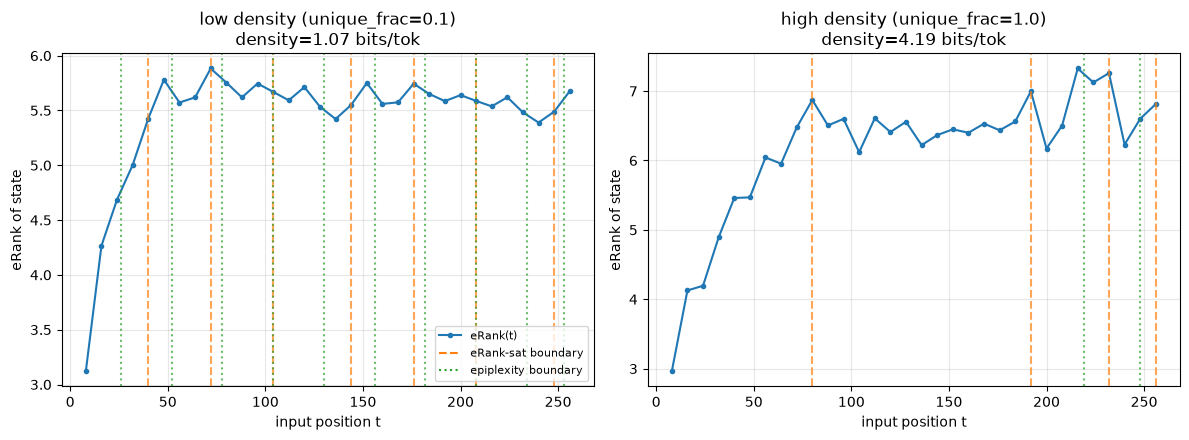

In [6]:
L = 256
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, uf, label in zip(axes, [0.1, 1.0], ["low density (unique_frac=0.1)", "high density (unique_frac=1.0)"]):
    ids = make_repetition_sequence(pool, L=L, unique_frac=uf, seed=0)
    dens = realized_density(bundle, ids)
    ks, vals = erank_curve(bundle, ids, 0, stride=8)
    ax.plot(ks, vals, marker=".", color="C0", label="eRank(t)")
    for b in segment_by_erank(bundle, ids):
        ax.axvline(b, color="C1", ls="--", alpha=.7)
    for b in segment_by_epiplexity(bundle, ids):
        ax.axvline(b, color="C2", ls=":", alpha=.7)
    ax.set_title(f"{label}\ndensity={dens:.2f} bits/tok"); ax.set_xlabel("input position t")
    ax.set_ylabel("eRank of state"); ax.grid(alpha=.3)
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([0],[0],color="C0",marker="."),
                        Line2D([0],[0],color="C1",ls="--"),
                        Line2D([0],[0],color="C2",ls=":")],
               labels=["eRank(t)", "eRank-sat boundary", "epiplexity boundary"], fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "worked_example_boundaries.png"), dpi=120)
plt.show()

## 6. Main experiment — chunk length vs information density
Sweep `unique_frac` (density knob) × seeds; for each, measure realized density (bits/token) and the
mean chunk length under both criteria.

In [7]:
DENSITY_LEVELS = [0.1, 0.2, 0.35, 0.6, 1.0]   # unique_frac
L, N_SEQ = 256, 4
rows = []
for uf in DENSITY_LEVELS:
    for s in range(N_SEQ):
        ids = make_repetition_sequence(pool, L=L, unique_frac=uf, seed=s)
        dens = realized_density(bundle, ids)
        cle = chunk_lengths(segment_by_erank(bundle, ids), L)
        clp = chunk_lengths(segment_by_epiplexity(bundle, ids), L)
        rows.append({"unique_frac": uf, "seed": s, "density_bits_per_tok": dens,
                     "erank_mean_chunk": float(np.mean(cle)), "erank_n_chunks": len(cle),
                     "epi_mean_chunk": float(np.mean(clp)), "epi_n_chunks": len(clp)})
        print(f"uf={uf:.2f} seed={s} density={dens:5.2f} | "
              f"eRank chunk~{np.mean(cle):5.1f} ({len(cle)}) | epi chunk~{np.mean(clp):5.1f} ({len(clp)})")
with open(os.path.join(RESULTS_DIR, "chunk_by_density.json"), "w") as f:
    json.dump(rows, f, indent=2)

uf=0.10 seed=0 density= 1.07 | eRank chunk~ 32.0 (8) | epi chunk~ 23.3 (11)


uf=0.10 seed=1 density= 1.03 | eRank chunk~ 36.6 (7) | epi chunk~ 23.3 (11)


uf=0.10 seed=2 density= 0.83 | eRank chunk~ 32.0 (8) | epi chunk~ 23.3 (11)


uf=0.10 seed=3 density= 0.62 | eRank chunk~ 32.0 (8) | epi chunk~ 23.3 (11)


uf=0.20 seed=0 density= 1.42 | eRank chunk~ 51.2 (5) | epi chunk~ 42.7 (6)


...

uf=0.60 seed=3 density= 3.01 | eRank chunk~ 64.0 (4) | epi chunk~ 85.3 (3)


uf=1.00 seed=0 density= 4.19 | eRank chunk~ 64.0 (4) | epi chunk~ 85.3 (3)


uf=1.00 seed=1 density= 5.39 | eRank chunk~ 51.2 (5) | epi chunk~ 85.3 (3)


uf=1.00 seed=2 density= 4.61 | eRank chunk~ 85.3 (3) | epi chunk~ 85.3 (3)


uf=1.00 seed=3 density= 4.50 | eRank chunk~ 51.2 (5) | epi chunk~ 85.3 (3)


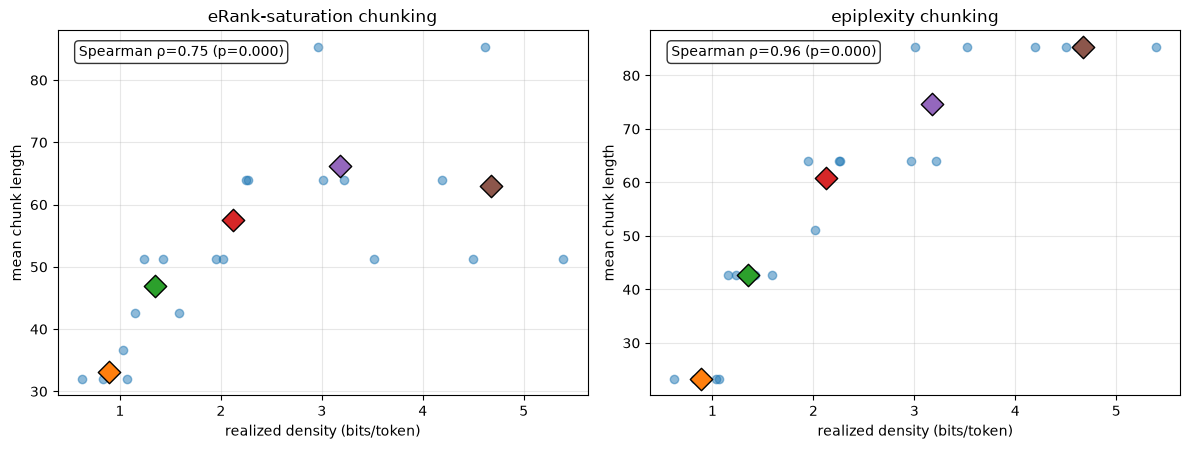

ρ>0 => chunk length grows with density (saturation view B); ρ<0 => shrinks with density (compression view A).


In [8]:
# 6.1 chunk length vs density, both criteria (+ Spearman rho -> which hypothesis)
from scipy.stats import spearmanr
dens = np.array([r["density_bits_per_tok"] for r in rows])
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
for a, (key, title) in zip(ax, [("erank_mean_chunk", "eRank-saturation chunking"),
                                ("epi_mean_chunk", "epiplexity chunking")]):
    y = np.array([r[key] for r in rows])
    a.scatter(dens, y, alpha=.5, label="samples")
    for uf in DENSITY_LEVELS:                       # per-density-level mean (diamonds)
        m = [r for r in rows if r["unique_frac"] == uf]
        a.scatter(np.mean([r["density_bits_per_tok"] for r in m]),
                  np.mean([r[key] for r in m]), s=130, marker="D", edgecolor="k", zorder=5)
    rho, p = spearmanr(dens, y)
    a.text(.04, .96, f"Spearman ρ={rho:.2f} (p={p:.3f})", transform=a.transAxes, va="top",
           bbox=dict(boxstyle="round", fc="w", alpha=.8))
    a.set_xlabel("realized density (bits/token)"); a.set_ylabel("mean chunk length")
    a.set_title(title); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "chunk_by_density.png"), dpi=120)
plt.show()
print("ρ>0 => chunk length grows with density (saturation view B); "
      "ρ<0 => shrinks with density (compression view A).")

## 7. Interpretation & next steps

- **Read the sign of Spearman ρ** in §6.1: it decides between the compression view (A, ρ<0) and the
  saturation view (B, ρ>0), for each criterion. Agreement/disagreement between the two criteria is
  itself informative about what "capacity plateau" means.

**TODO (this notebook, next pass):**
1. Multi-seed CIs on ρ; robustness to `sat_frac`, `stride`, `min_len`, `L`.
2. Natural-passage density (bin real WikiText passages by bits/token) as a non-synthetic cross-check.
3. Add `gdn-340m` (MoM state reset is per-memory — needs care).
4. Report chunk-length *distributions*, not just means.

**Deferred to a separate notebook — (3):** take the chunked/snapshotted states and test whether the
**SSC** scheme from the LLM-memory-routing repo can still route/reuse them (does state reuse survive
density-adaptive chunk boundaries?).